<a href="https://colab.research.google.com/github/NiteshJ98/LLM-from-scratch/blob/main/Layer%201/Phase%202/LossFunctions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loss functions**

They are the signal that tells the model what's wrong and by how much. Everything in training — the gradients, the weight updates, the direction the model moves — flows entirely from the loss. Getting this right conceptually is one of the most important things in Layer 1

**The core idea**

A loss function takes two things — what the model predicted, and what actually happened — and returns a single number measuring how wrong the prediction was. The goal of training is to minimize this number.

Three properties a good loss function must have: it must be differentiable (so gradients can flow), it must be zero when prediction is perfect, and it must grow as predictions get worse.

**MSE — Mean Squared Error**

Used for regression — predicting a continuous number (house price, temperature, stock value).

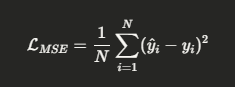

Where ŷ is the prediction and y is the true value. The squaring does two important things: it makes all errors positive (so under- and over-prediction don't cancel), and it penalizes large errors disproportionately — a prediction that's 2× further away gets 4× the loss. This makes the model aggressively correct big mistakes.

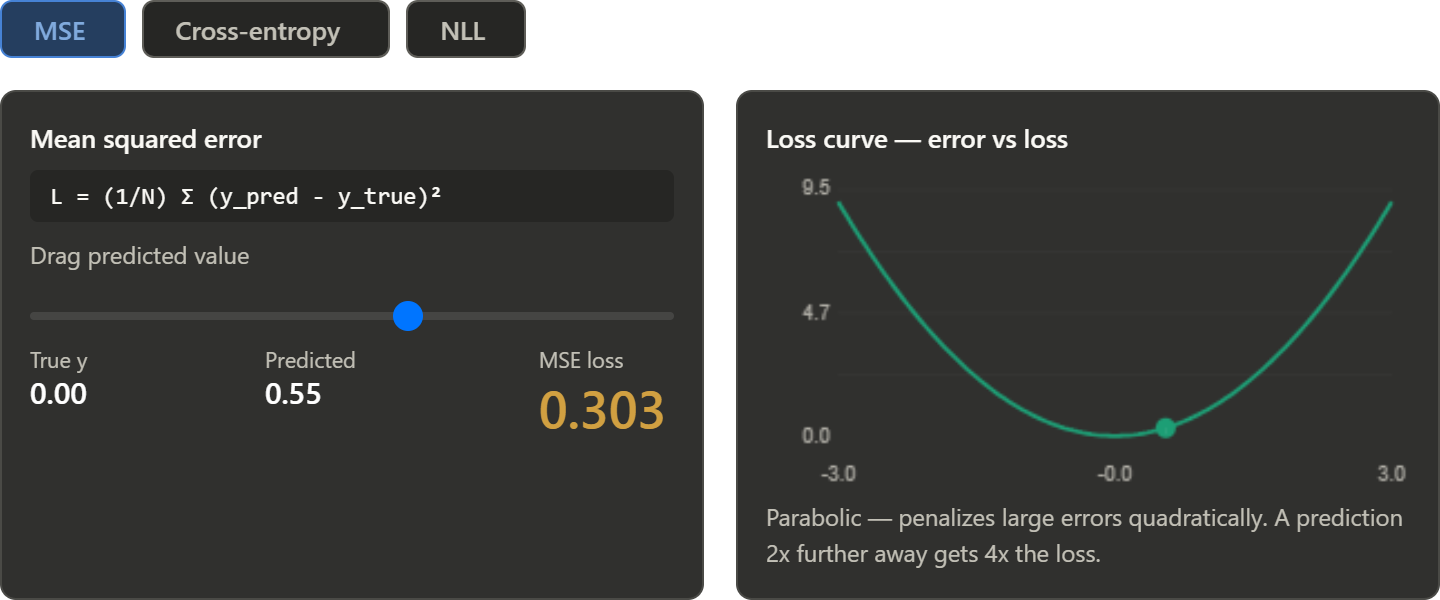

In [2]:
import torch
import torch.nn as nn

loss_fn = nn.MSELoss()

# Regression: predicting house prices (in $100k)
y_pred = torch.tensor([3.2, 5.1, 2.8, 4.5])   # model's guesses
y_true = torch.tensor([3.0, 5.0, 3.0, 4.0])   # actual prices

loss = loss_fn(y_pred, y_true)
print(f"MSE loss: {loss.item():.4f}")   # 0.0875

# Manual verification
errors = y_pred - y_true
print(f"Errors:         {errors}")              # [ 0.2,  0.1, -0.2,  0.5]
print(f"Squared errors: {errors ** 2}")         # [0.04, 0.01, 0.04, 0.25]
print(f"Mean:           {(errors**2).mean()}")  # 0.0875 ✓

# Notice: the 0.5 error contributes 0.25 to the loss
# while the 0.1 error contributes only 0.01 — 25x less,
# despite being only 5x smaller. That's the squaring effect.

# What the gradient looks like — points toward reducing big errors first
y_pred_grad = torch.tensor([3.2, 5.1, 2.8, 4.5], requires_grad=True)
loss = loss_fn(y_pred_grad, y_true)
loss.backward()
print(f"Gradients: {y_pred_grad.grad}")
# tensor([ 0.1000,  0.0500, -0.1000,  0.2500])
# Gradient = 2/N * (pred - true) — largest where error is largest

MSE loss: 0.0850
Errors:         tensor([ 0.2000,  0.1000, -0.2000,  0.5000])
Squared errors: tensor([0.0400, 0.0100, 0.0400, 0.2500])
Mean:           0.08500000834465027
Gradients: tensor([ 0.1000,  0.0500, -0.1000,  0.2500])


**When NOT to use MSE:** when your targets have outliers. A single wildly wrong data point gets squared, dominates the loss, and pulls the whole model toward it. In that case use MAE (Mean Absolute Error, `nn.L1Loss`) which is more robust.

**Cross-Entropy Loss**

Used for classification — predicting which category something belongs to. This is the loss used in language models, image classifiers, and virtually every discrete prediction task.

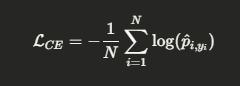

 where the argument inside log function is the probability the model assigned to the *correct* class for example i. You only look at the probability of the right answer — everything else is irrelevant to the loss value itself (though it affects the gradient).

The key insight: this is just `−log(confidence in correct answer)`. When confidence is 1.0, loss is 0. When confidence is 0.01, loss is 4.6. The log curve means being very wrong is punished catastrophically.

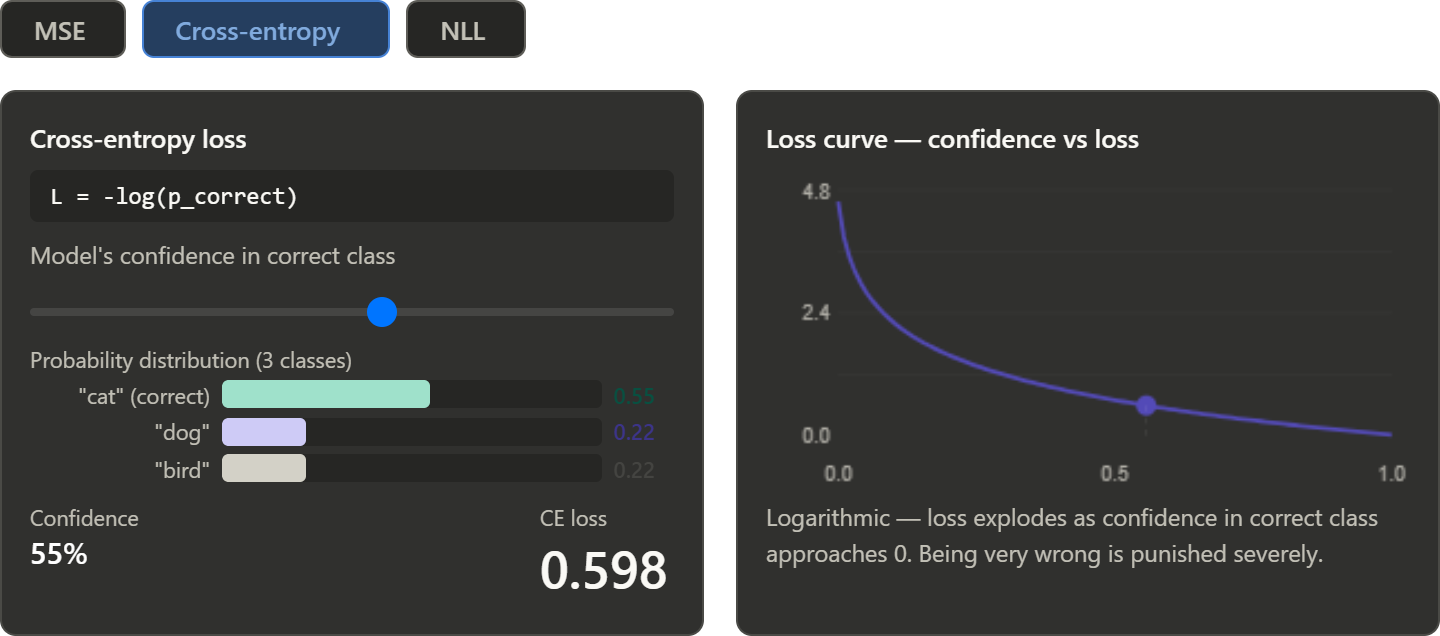

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

loss_fn = nn.CrossEntropyLoss()

# Classification: 3 examples, 4 classes (cat / dog / bird / fish)
# Raw model outputs — called LOGITS (before softmax)
logits = torch.tensor([
    [ 2.5,  0.3, -1.0,  0.8],   # example 1
    [-0.5,  3.1,  0.2, -0.3],   # example 2
    [ 0.1,  0.4,  2.8,  0.1],   # example 3
])

true_labels = torch.tensor([0, 1, 2])   # cat, dog, bird

loss = loss_fn(logits, true_labels)
print(f"CE loss: {loss.item():.4f}")   # ~0.1887

# What CrossEntropyLoss does internally — three steps:
# Step 1: softmax — convert logits to probabilities
probs = F.softmax(logits, dim=1)
print(f"\nProbabilities:\n{probs.round(decimals=3)}")
# tensor([[0.827, 0.091, 0.025, 0.151],   ← correct class 0: 82.7% confidence
#         [0.030, 0.887, 0.059, 0.029],   ← correct class 1: 88.7% confidence
#         [0.066, 0.091, 0.775, 0.066]])  ← correct class 2: 77.5% confidence

# Step 2: pick out probability of correct class
correct_probs = probs[range(3), true_labels]
print(f"\nProb of correct class: {correct_probs}")
# tensor([0.827, 0.887, 0.775])

# Step 3: -log, then mean
manual_loss = -torch.log(correct_probs).mean()
print(f"Manual CE loss: {manual_loss.item():.4f}")   # matches ✓

# In an LLM, this is exactly what happens:
# logits shape: (batch, seq_len, vocab_size)
# labels shape: (batch, seq_len)
# CE loss = average -log(prob of next correct token) across all positions

CE loss: 0.1977

Probabilities:
tensor([[0.7550, 0.0840, 0.0230, 0.1380],
        [0.0240, 0.8960, 0.0490, 0.0300],
        [0.0550, 0.0740, 0.8160, 0.0550]])

Prob of correct class: tensor([0.7555, 0.8963, 0.8162])
Manual CE loss: 0.1977


A critical implementation detail: `nn.CrossEntropyLoss` expects raw logits, not probabilities. It applies softmax internally. If you pass it softmax outputs, you get wrong results silently — one of the most common bugs.

In [4]:
# WRONG — double softmax
probs = F.softmax(logits, dim=1)
bad_loss = loss_fn(probs, true_labels)   # silently wrong

# RIGHT — pass raw logits
good_loss = loss_fn(logits, true_labels)  # correct ✓

**NLL Loss — Negative Log Likelihood**

NLL loss and cross-entropy are mathematically identical — they just expect different inputs. NLL expects log-probabilities (output of log_softmax), while CE expects raw logits.

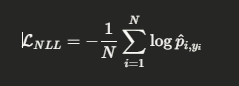

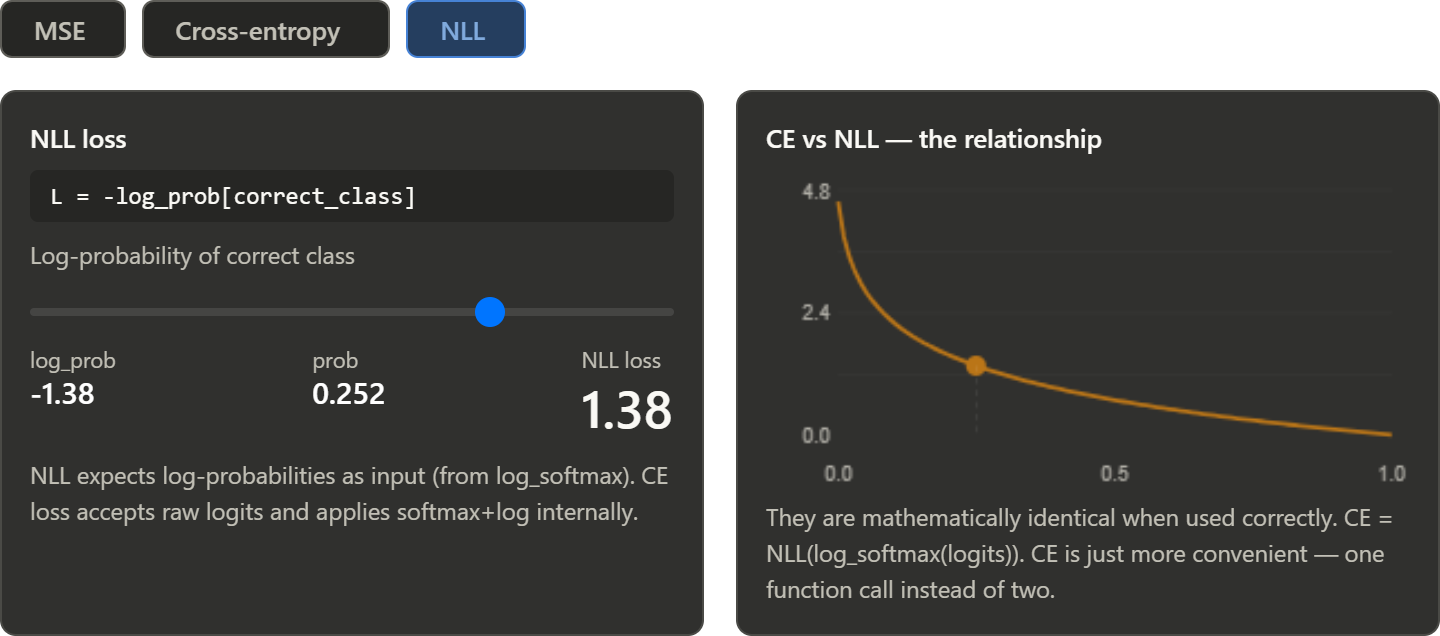

In [5]:
import torch.nn.functional as F

# NLL route — two steps explicit
log_probs = F.log_softmax(logits, dim=1)   # shape (3, 4), values all negative
loss_nll   = nn.NLLLoss()(log_probs, true_labels)

# CE route — one step, softmax+log baked in
loss_ce = nn.CrossEntropyLoss()(logits, true_labels)

print(f"NLL loss: {loss_nll.item():.6f}")
print(f"CE  loss: {loss_ce.item():.6f}")
# NLL loss: 0.188700
# CE  loss: 0.188700   ← identical ✓

# Why does NLL exist then? Because sometimes you want log_softmax
# outputs for other reasons (e.g. beam search in text generation)
# and don't want to recompute them. You can reuse them directly.

# log_softmax is also numerically more stable than log(softmax(x))
# because it avoids computing the intermediate softmax (which can overflow)
print(log_probs[0])
# tensor([-0.1904, -2.3904, -3.6904, -1.8904]) — log of probabilities

NLL loss: 0.197655
CE  loss: 0.197655
tensor([-0.2804, -2.4804, -3.7804, -1.9804])


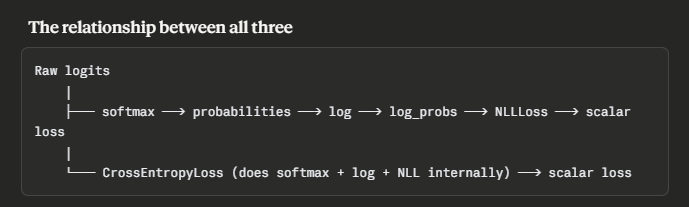

For LLM fine-tuning, you will exclusively use `CrossEntropyLoss` on raw logits. The HuggingFace `Trainer` applies it automatically — but knowing what it's computing means you can interpret your loss values meaningfully.



**Interpreting loss values**

This is something most tutorials skip. What does a loss of 2.3 actually mean?

In [6]:
import math

# For cross-entropy, a useful reference point:
# If the model assigns EQUAL probability to all classes (random guessing):
# loss = -log(1 / num_classes) = log(num_classes)

n_classes = [2, 10, 100, 50257]   # binary, digits, misc, GPT-2 vocab

print("Random-chance CE loss by vocab size:")
for n in n_classes:
    print(f"  {n:6d} classes → loss = {math.log(n):.2f}")

# 2 classes  → loss = 0.69   (binary classifier guessing randomly)
# 10 classes → loss = 2.30   (digit classifier guessing randomly)
# 50257 classes → loss = 10.82  (GPT-2 token prediction, completely random)

Random-chance CE loss by vocab size:
       2 classes → loss = 0.69
      10 classes → loss = 2.30
     100 classes → loss = 4.61
   50257 classes → loss = 10.82


This gives you a sanity check. If your language model starts at loss ~10.8 on a 50k vocab and drops to ~2.0 after training, it's learned a lot. If it starts at 10.8 and only drops to 9.5, something is badly wrong.

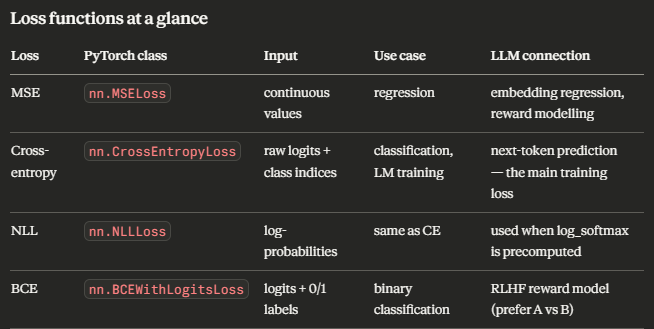

**Hands-on exercise**

In [7]:
import torch, torch.nn as nn, torch.nn.functional as F

# Part 1 — MSE
pred = torch.tensor([1.0, 2.0, 3.0])
true = torch.tensor([1.5, 1.5, 4.0])
print(nn.MSELoss()(pred, true))        # what do you expect?

tensor(0.5000)


In [8]:
# Part 2 — CE with a confident correct prediction
logits_good = torch.tensor([[10.0, 0.0, 0.0]])
logits_bad  = torch.tensor([[0.0, 10.0, 0.0]])
label = torch.tensor([0])
print(nn.CrossEntropyLoss()(logits_good, label))   # near 0?
print(nn.CrossEntropyLoss()(logits_bad,  label))   # large?

tensor(9.0833e-05)
tensor(10.0001)


In [9]:
# Part 3 — verify CE == NLL manually
logits = torch.tensor([[2.0, 1.0, 0.5]])
label  = torch.tensor([0])
ce  = nn.CrossEntropyLoss()(logits, label)
lp  = F.log_softmax(logits, dim=1)
nll = nn.NLLLoss()(lp, label)
print(f"CE={ce.item():.4f}  NLL={nll.item():.4f}  equal={torch.isclose(ce, nll)}")

CE=0.4644  NLL=0.4644  equal=True


In [10]:
# Part 4 — random chance baseline for 10-class problem
import math
print(f"Random baseline loss: {math.log(10):.4f}")
logits_random = torch.zeros(1, 10)
print(f"Uniform logits loss:  {nn.CrossEntropyLoss()(logits_random, torch.tensor([0])).item():.4f}")

Random baseline loss: 2.3026
Uniform logits loss:  2.3026


In [ ]:
from IPython.display import HTML, display

html_file_url = 'YOUR_HTML_FILE_URL_HERE' # <--- REPLACE THIS with the actual URL of your HTML file

# Display a clickable link
display(HTML(f'Click <a href="{html_file_url}" target="_blank">here</a> to open your Loss Function Explorer.'))

This will open the HTML file in a new browser tab when you click the link. This method often provides the best interactivity for complex browser-based applications.